<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FResNet50-Model/ResNet50C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [ ]:
SEED = 123

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
VAL_DIR = os.path.join(DATASET_DIR, "Validation")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /content/drive/MyDrive/dataset/Train
Validation: /content/drive/MyDrive/dataset/Validation
Test: /content/drive/MyDrive/dataset/Test


In [ ]:
for directory in [TRAIN_DIR, os.path.join(DATASET_DIR, "Validation"), TEST_DIR]:

    print("\n", directory)

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

            print(f"{class_name}: {count}")


 /content/drive/MyDrive/dataset/Train
Eczema: 1081
Leishmaniasis: 524
Tinea: 1075

 /content/drive/MyDrive/dataset/Validation
Eczema: 231
Leishmaniasis: 112
Tinea: 231

 /content/drive/MyDrive/dataset/Test
Eczema: 232
Leishmaniasis: 113
Tinea: 228


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

EPOCHS_INITIAL = 10
EPOCHS_FINE_TUNE = 10

INITIAL_LEARNING_RATE = 1e-4
FINE_TUNE_LEARNING_RATE = 1e-5

DROPOUT_RATE = 0.3
FINE_TUNE_FROM = 160

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 2680 files belonging to 3 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "Validation"),
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 574 files belonging to 3 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 573 files belonging to 3 classes.


In [ ]:
class_names = train_ds.class_names

print("Class names:")
print(class_names)

Class names:
['Eczema', 'Leishmaniasis', 'Tinea']


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
], name="data_augmentation")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

In [ ]:
inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image"
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(DROPOUT_RATE)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    262,272 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 3)         │        387 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,563 (91.01 MB)

 Trainable params: 266,755 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
optimizer = keras.optimizers.Adam(
    learning_rate=INITIAL_LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INITIAL,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 713s 8s/step - accuracy: 0.9772 - loss: 0.0609 - val_accuracy: 0.9721 - val_loss: 0.0959 - learning_rate: 1.0000e-04
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 757s 9s/step - accuracy: 0.9795 - loss: 0.0592 - val_accuracy: 0.9704 - val_loss: 0.0982 - learning_rate: 1.0000e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 728s 9s/step - accuracy: 0.9840 - loss: 0.0548 - val_accuracy: 0.9791 - val_loss: 0.0939 - learning_rate: 1.0000e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 725s 9s/step - accuracy: 0.9813 - loss: 0.0535 - val_accuracy: 0.9704 - val_loss: 0.0918 - learning_rate: 1.0000e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 722s 8s/step - accuracy: 0.9854 - loss: 0.0420 - val_accuracy: 0.9756 - val_loss: 0.0848 - learning_rate: 1.0000e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 699s 8s/step - accuracy: 0.9862 - loss: 0.0434 - val_accuracy: 0.9739 - val_loss: 0.0810 - learning_rate: 1.0000e-04
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 743s 8s/step - accuracy: 0.9869 

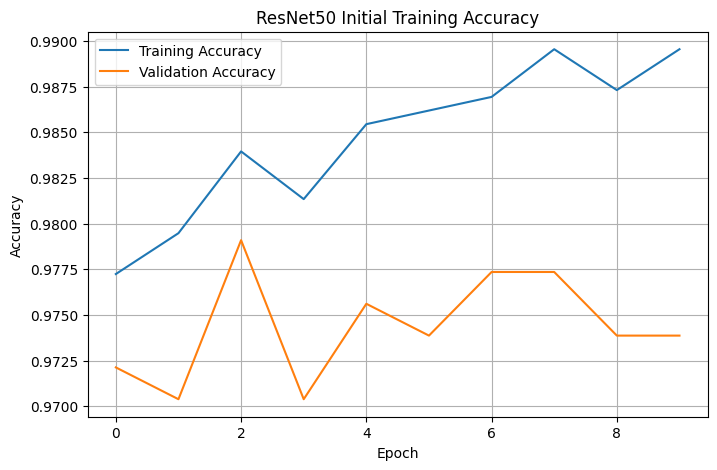

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_initial.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_initial.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Initial Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

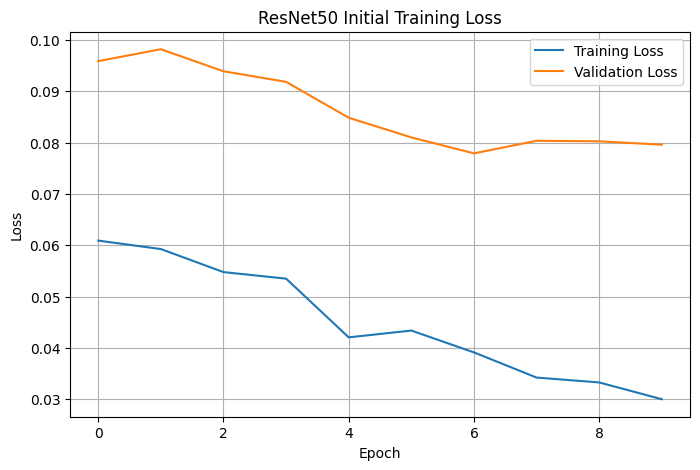

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_initial.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_initial.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Initial Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

for layer in base_model.layers[FINE_TUNE_FROM:]:
    layer.trainable = True

In [ ]:
trainable_layers = sum(
    1 for layer in model.layers
    if layer.trainable
)

total_layers = len(model.layers)

print("Trainable layers:", trainable_layers)
print("Total layers:", total_layers)

Trainable layers: 9
Total layers: 9


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 848s 10s/step - accuracy: 0.9821 - loss: 0.0512 - val_accuracy: 0.9791 - val_loss: 0.0862 - learning_rate: 1.0000e-05
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9856 - loss: 0.0421
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 859s 10s/step - accuracy: 0.9858 - loss: 0.0423 - val_accuracy: 0.9756 - val_loss: 0.0846 - learning_rate: 1.0000e-05
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 857s 10s/step - accuracy: 0.9858 - loss: 0.0377 - val_accuracy: 0.9756 - val_loss: 0.0843 - learning_rate: 2.0000e-06
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9924 - loss: 0.0281
Epoch 4: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
84/84 ━━━━━━━━━━━━━━━━━━━━ 807s 10s/step - accuracy: 0.9899 - loss: 0.0345 - val_accuracy: 0.9756 - val_loss: 0.0845 - learning_rate: 2.0000e-06
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 804s 10s/step - accuracy: 0.9854 - loss: 

In [ ]:
acc = (
    history_initial.history["accuracy"]
    + history_fine.history["accuracy"]
)

val_acc = (
    history_initial.history["val_accuracy"]
    + history_fine.history["val_accuracy"]
)

loss = (
    history_initial.history["loss"]
    + history_fine.history["loss"]
)

val_loss = (
    history_initial.history["val_loss"]
    + history_fine.history["val_loss"]
)

epochs_range = range(1, len(acc) + 1)

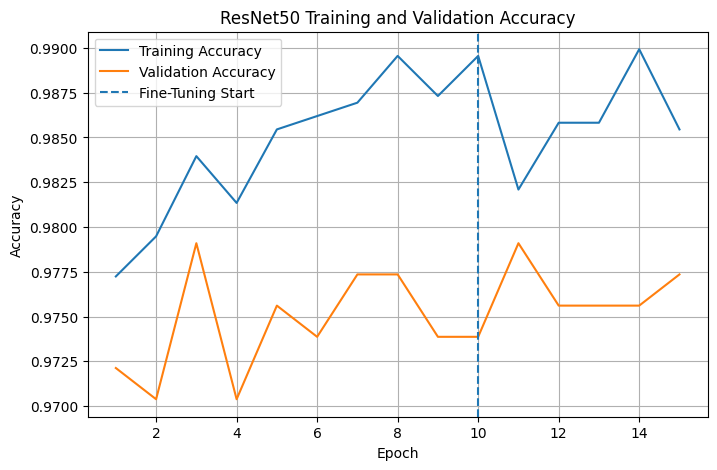

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)

plt.axvline(
    x=len(history_initial.history["accuracy"]),
    linestyle="--",
    label="Fine-Tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

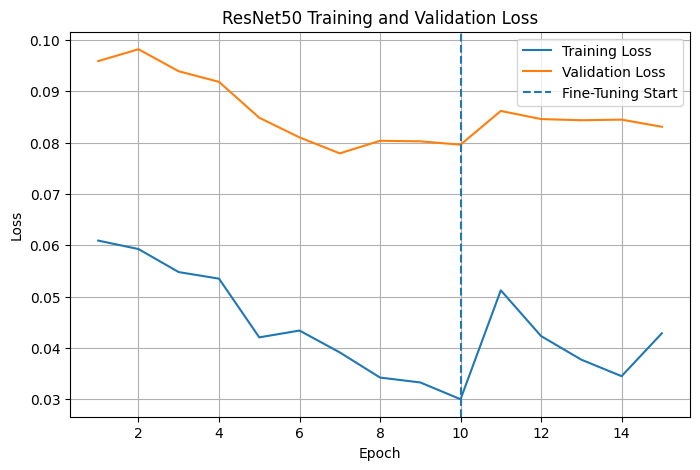

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    x=len(history_initial.history["loss"]),
    linestyle="--",
    label="Fine-Tuning Start"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 130s 7s/step - accuracy: 0.9721 - loss: 0.0768
Test Loss: 0.0768
Test Accuracy: 0.9721


In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

    y_prob.extend(predictions)

In [ ]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

               precision    recall  f1-score   support

       Eczema     1.0000    0.9828    0.9913       232
Leishmaniasis     0.9714    0.9027    0.9358       113
        Tinea     0.9458    0.9956    0.9701       228

     accuracy                         0.9721       573
    macro avg     0.9724    0.9603    0.9657       573
 weighted avg     0.9728    0.9721    0.9719       573



In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9721
Precision: 0.9728
Recall   : 0.9721
F1-score : 0.9719


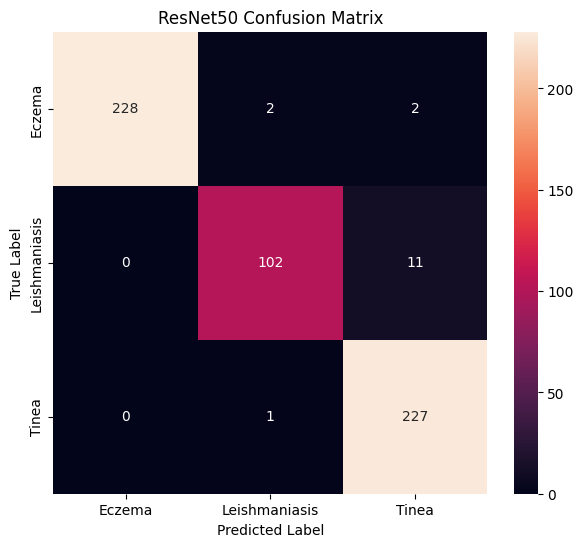

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")

plt.show()

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

for class_name in class_names:

    print(
        f"{class_name}: "
        f"Recall = {report[class_name]['recall']:.4f}"
    )

Eczema: Recall = 0.9828
Leishmaniasis: Recall = 0.9027
Tinea: Recall = 0.9956


In [ ]:
specificity_results = {}

for i, class_name in enumerate(class_names):

    true_negative = np.sum(
        np.delete(
            np.delete(cm, i, axis=0),
            i,
            axis=1
        )
    )

    false_positive = np.sum(
        cm[:, i]
    ) - cm[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_results[class_name] = specificity

    print(
        f"{class_name} Specificity: "
        f"{specificity:.4f}"
    )

Eczema Specificity: 1.0000
Leishmaniasis Specificity: 0.9935
Tinea Specificity: 0.9623


In [ ]:
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

In [ ]:
auc_scores = {}

for i, class_name in enumerate(class_names):

    auc_score = roc_auc_score(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    auc_scores[class_name] = auc_score

    print(
        f"{class_name} ROC-AUC: "
        f"{auc_score:.4f}"
    )

Eczema ROC-AUC: 0.9998
Leishmaniasis ROC-AUC: 0.9964
Tinea ROC-AUC: 0.9984


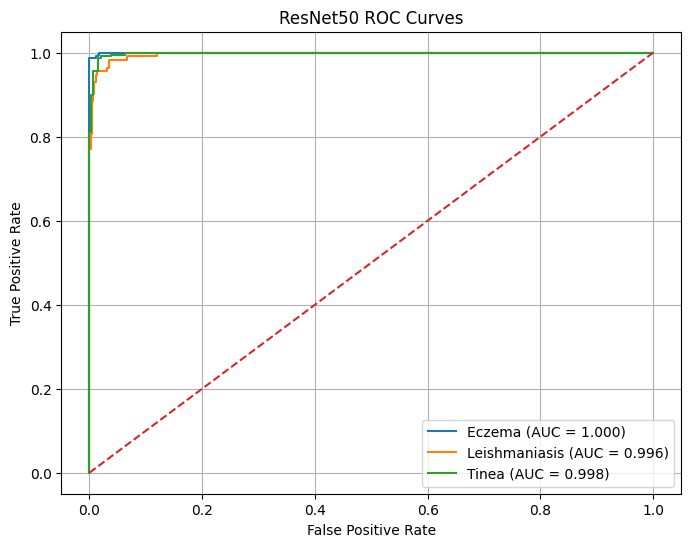

In [ ]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ResNet50 ROC Curves")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ResNet50_Models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

In [ ]:
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "resnet50_tinea_classifier.keras"
)

model.save(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

NameError: name 'model' is not defined

In [ ]:
import json

CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR,
    "class_names.json"
)

with open(
    CLASS_NAMES_PATH,
    "w"
) as f:

    json.dump(
        class_names,
        f
    )

print("Class names saved.")

Class names saved.


In [ ]:
MODEL_PATH = os.path.join(
    MODEL_DIR,
    "resnet50_tinea_classifier.keras"
)

loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Model loaded successfully.")

NameError: name 'MODEL_PATH' is not defined

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving testTinea1.jfif to testTinea1 (1).jfif


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

IMG_SIZE = 224

image_path = list(uploaded.keys())[0]

image = load_img(
    image_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

image_array = img_to_array(image)

image_array = np.expand_dims(
    image_array,
    axis=0
)

In [ ]:
prediction = model.predict(
    image_array,
    verbose=0
)

probabilities = prediction[0]

predicted_index = np.argmax(
    probabilities
)

predicted_class = class_names[
    predicted_index
]

confidence = probabilities[
    predicted_index
]

print("Predicted disease:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

NameError: name 'model' is not defined

In [ ]:
for class_name, probability in zip(
    class_names,
    probabilities
):

    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

Eczema: 0.19%
Leishmaniasis: 24.23%
Tinea: 75.57%
